# Traffic flow forecast 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import month_plot, quarter_plot, plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import seaborn as sns

In [44]:

data_loc = r"~/Desktop/Data Playground/Traffic Flow Forecasting and Analysis"
data_name="traffic_sensor_data.csv"
df = pd.read_csv(f"{data_loc}/{data_name}")

## EDA

In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 218400 entries, 0 to 218399
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   timestamp          218400 non-null  str    
 1   sensor_id          218400 non-null  str    
 2   location           218400 non-null  str    
 3   direction          218400 non-null  str    
 4   vehicle_count      218400 non-null  int64  
 5   average_speed_kmh  218400 non-null  float64
 6   occupancy_rate     218400 non-null  float64
 7   congestion_level   218400 non-null  str    
 8   car_count          218400 non-null  int64  
 9   motorcycle_count   218400 non-null  int64  
 10  truck_count        218400 non-null  int64  
 11  bus_count          218400 non-null  int64  
 12  day_of_week        218400 non-null  int64  
 13  is_holiday         218400 non-null  int64  
 14  hour               218400 non-null  int64  
dtypes: float64(2), int64(8), str(5)
memory usage: 25.0 MB


In [46]:
df.head()

,timestamp,sensor_id,location,direction,vehicle_count,average_speed_kmh,occupancy_rate,congestion_level,car_count,motorcycle_count,truck_count,bus_count,day_of_week,is_holiday,hour
0,2024-01-01 00:00:00,SEN-001,Jl. Sudirman - Bundaran HI,North,14,67.8,0.073,Low,6,5,1,2,0,1,0
1,2024-01-01 00:00:00,SEN-002,Jl. Thamrin - Monas,South-West,23,66.8,0.075,Low,10,8,1,4,0,1,0
2,2024-01-01 00:00:00,SEN-003,Jl. Gatot Subroto - Kuningan,East,22,80.0,0.161,Low,7,9,1,5,0,1,0
3,2024-01-01 00:00:00,SEN-004,Jl. Rasuna Said - Setiabudi,East,8,80.0,0.055,Low,3,2,0,3,0,1,0
4,2024-01-01 00:00:00,SEN-005,Jl. HR Rasuna Said - Casablanca,East,13,80.0,0.097,Low,5,5,0,3,0,1,0


In [47]:
df["sensor_id"].unique()

<StringArray>
['SEN-001', 'SEN-002', 'SEN-003', 'SEN-004', 'SEN-005', 'SEN-006', 'SEN-007',
 'SEN-008', 'SEN-009', 'SEN-010', 'SEN-011', 'SEN-012', 'SEN-013', 'SEN-014',
 'SEN-015', 'SEN-016', 'SEN-017', 'SEN-018', 'SEN-019', 'SEN-020', 'SEN-021',
 'SEN-022', 'SEN-023', 'SEN-024', 'SEN-025', 'SEN-026', 'SEN-027', 'SEN-028',
 'SEN-029', 'SEN-030', 'SEN-031', 'SEN-032', 'SEN-033', 'SEN-034', 'SEN-035',
 'SEN-036', 'SEN-037', 'SEN-038', 'SEN-039', 'SEN-040', 'SEN-041', 'SEN-042',
 'SEN-043', 'SEN-044', 'SEN-045', 'SEN-046', 'SEN-047', 'SEN-048', 'SEN-049',
 'SEN-050']
Length: 50, dtype: str

In [48]:
df[df['sensor_id'] == 'SEN-002']

,timestamp,sensor_id,location,direction,vehicle_count,average_speed_kmh,occupancy_rate,congestion_level,car_count,motorcycle_count,truck_count,bus_count,day_of_week,is_holiday,hour
1,2024-01-01 00:00:00,SEN-002,Jl. Thamrin - Monas,South-West,23,66.8,0.075,Low,10,8,1,4,0,1,0
51,2024-01-01 00:30:00,SEN-002,Jl. Thamrin - Monas,South,28,80.0,0.183,Low,10,9,2,7,0,1,0
101,2024-01-01 01:00:00,SEN-002,Jl. Thamrin - Monas,South-West,24,80.0,0.154,Low,9,10,2,3,0,1,1
151,2024-01-01 01:30:00,SEN-002,Jl. Thamrin - Monas,South,28,80.0,0.176,Low,11,11,2,4,0,1,1
201,2024-01-01 02:00:00,SEN-002,Jl. Thamrin - Monas,South-West,11,80.0,0.083,Low,5,4,0,2,0,1,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
218151,2024-03-31 21:30:00,SEN-002,Jl. Thamrin - Monas,South,23,80.0,0.087,Low,8,8,1,6,6,1,21
218201,2024-03-31 22:00:00,SEN-002,Jl. Thamrin - Monas,North-East,21,80.0,0.110,Low,9,8,1,3,6,1,22
218251,2024-03-31 22:30:00,SEN-002,Jl. Thamrin - Monas,South-West,27,80.0,0.072,Low,13,9,2,3,6,1,22
218301,2024-03-31 23:00:00,SEN-002,Jl. Thamrin - Monas,South-West,8,80.0,0.050,Low,3,2,0,3,6,1,23


In [55]:
df.keys()

Index(['timestamp', 'sensor_id', 'location', 'direction', 'vehicle_count',
       'average_speed_kmh', 'occupancy_rate', 'congestion_level', 'car_count',
       'motorcycle_count', 'truck_count', 'bus_count', 'day_of_week',
       'is_holiday', 'hour'],
      dtype='str')

In [56]:
df['is_holiday'].unique()

array([1, 0])

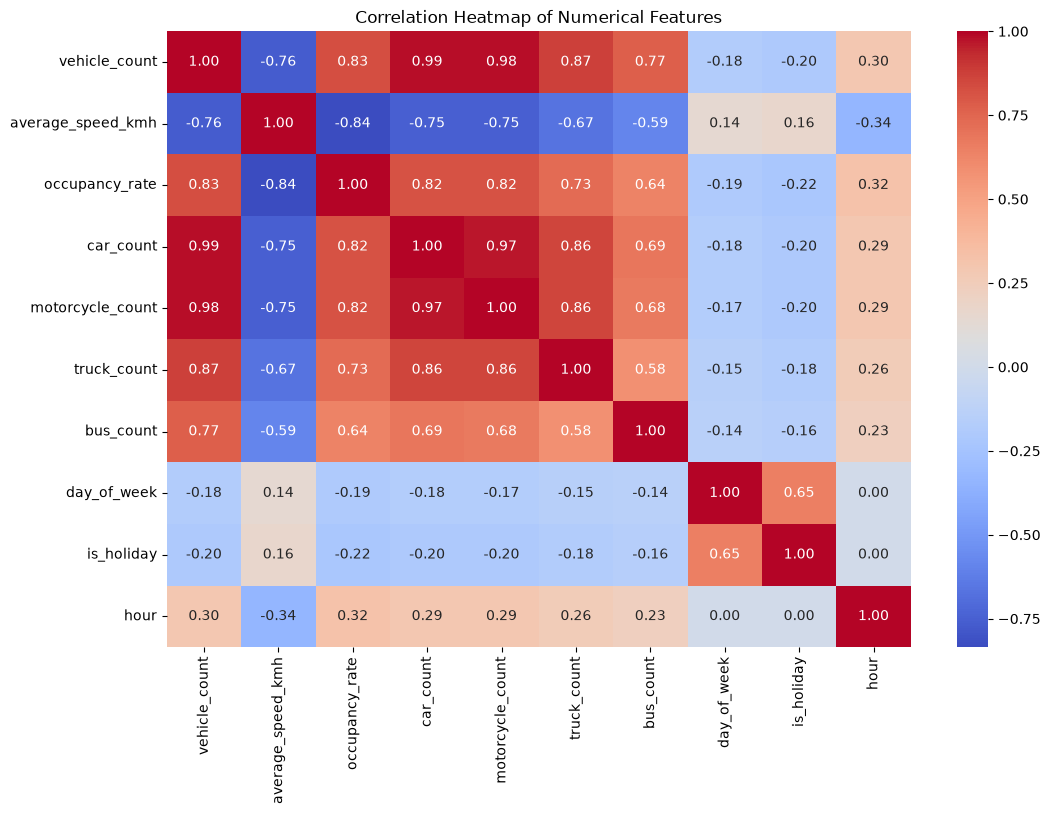

In [ ]:
import seaborn as sns

# Calculate correlation matrix
corr = df.select_dtypes(include=['number']).corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

## Feature Engineering

In [ ]:
def feature_engineering(df):
    modern_df = df.copy()
    # Convert timestamp to datetime
    modern_df['timestamp'] = pd.to_datetime(modern_df['timestamp'])
    
    # Extract date and time features: One option
    modern_df['year'] = modern_df['timestamp'].dt.year
    modern_df['month'] = modern_df['timestamp'].dt.month
    modern_df['day'] = modern_df['timestamp'].dt.day
    modern_df['hour'] = modern_df['timestamp'].dt.hour
    modern_df['minute'] = modern_df['timestamp'].dt.minute
    modern_df['day_of_week'] = modern_df['timestamp'].dt.dayofweek

    # Encode congestion_level as numbers (Low: 1, Medium: 2)
    congestion_mapping = {'Low': 1, 'Medium': 2}
    modern_df['congestion_level'] = modern_df['congestion_level'].map(congestion_mapping)

    # One hot encoder for categorical features (sensor_id)
    #modern_df = pd.get_dummies(modern_df, columns=['sensor_id'], drop_first=True)


    modern_df.drop(columns=['timestamp','location','direction','car_count','motorcycle_count','truck_count','bus_count'], inplace=True)
    
    return modern_df

def classical_feature_engineering(df, time_column='timestamp', target_column='vehicle_count'):
    classical_df = df.copy()
    classical_df[time_column] = pd.to_datetime(classical_df[time_column])
    classical_df.set_index(time_column, inplace=True)

    classical_df = classical_df.rename(columns = {target_column: "y"})
    return classical_df

### Classical Approach

In [ ]:
classical_df = classical_feature_engineering(df, time_column='timestamp', target_column='vehicle_count')

In [ ]:
# Daily Closing Price Plot
classical_df["y"].plot()
plt.show()

In [ ]:
# Plot the ACF of the
fig, ax = plt.subplots(figsize = (12, 6))
plot_acf(classical_df['y'], lags = 100, ax = ax)
plt.show()

In [ ]:
# PACF
fig, ax = plt.subplots(figsize = (12, 6))
plot_pacf(classical_df['y'], lags = 100, ax = ax)
plt.show()

### Modern Approach

In [53]:
modern_df = feature_engineering(df)
modern_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 218400 entries, 0 to 218399
Data columns (total 60 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   vehicle_count      218400 non-null  int64  
 1   average_speed_kmh  218400 non-null  float64
 2   occupancy_rate     218400 non-null  float64
 3   congestion_level   218400 non-null  str    
 4   day_of_week        218400 non-null  int32  
 5   is_holiday         218400 non-null  int64  
 6   hour               218400 non-null  int32  
 7   year               218400 non-null  int32  
 8   month              218400 non-null  int32  
 9   day                218400 non-null  int32  
 10  minute             218400 non-null  int32  
 11  sensor_id_SEN-002  218400 non-null  bool   
 12  sensor_id_SEN-003  218400 non-null  bool   
 13  sensor_id_SEN-004  218400 non-null  bool   
 14  sensor_id_SEN-005  218400 non-null  bool   
 15  sensor_id_SEN-006  218400 non-null  bool   
 16  sensor_id_SEN

# Models 

### LightGBM/Catboost 

### TFT

### Modern Techniques: AutoGluon

In [60]:
from sklearn.tree import DecisionTreeRegressor

def select_features(df, target_column, threshold=0.01):
    """
    Selects features based on Decision Tree feature importance.
    """
    # Ensure we only use numerical columns
    numerical_df = df.select_dtypes(include=['number']).dropna()
    
    if target_column not in numerical_df.columns:
        print(f"Target column {target_column} not found in numerical columns.")
        return numerical_df.columns.tolist()

    X = numerical_df.drop(columns=[target_column])
    y = numerical_df[target_column]

    # Initialize and fit Decision Tree
    model = DecisionTreeRegressor(random_state=42)
    model.fit(X, y)

    # Get feature importances
    importances = pd.Series(model.feature_importances_, index=X.columns)
    
    # Select features above threshold
    selected_features = importances[importances > threshold].sort_values(ascending=False).index.tolist()
        
    return selected_features

# Example usage:
selected = select_features(modern_df, 'vehicle_count')
print("Selected Features:", selected)

Selected Features: ['occupancy_rate', 'average_speed_kmh', 'hour', 'day', 'day_of_week', 'month']
